# Salifort Motors Employee Retention Analysis

## Imports

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
df = pd.read_csv('HR_capstone_dataset.csv')

## Business Problem

Salifort Motors is experiencing high employee turnover, which increases costs through additonal spending on recruiting and training. The senior leadership team wants to understand what drives employees to leave and to identify at-risk employees before they leave.

The goals of this analysis are to:
1. Identify the key factors that contribute to employee turnover
2. Build a machine learning model that predicts whether an employee will leave
3. Provide actionable recommendations to improve employee retention

## Data Dictionary

The dataset contains 14,999 rows and 10 columns. Each row represents one employee.

| Column | Type | Description |
|--------|------|-------------|
| satisfaction_level | float | Employee's self-reported satisfaction level [0-1] |
| last_evaluation | float | Score of employee's last performance review [0-1] |
| number_project | int | Number of projects employee contributes to |
| average_monthly_hours | int | Average number of hours worked per month |
| time_spend_company | int | Tenure at the company (years) |
| work_accident | int | Whether the employee had a workplace accident (0/1) |
| left | int | Whether the employee left the company (0/1) — target variable |
| promotion_last_5years | int | Whether the employee was promoted in the last 5 years (0/1) |
| department | str | The employee's department |
| salary | str | Salary level (low, medium, high) |

## Data Understanding

In [4]:
df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


The first 10 rows confirm that the data has loaded correctly. The structure matches data dictionary. Numerical features are in expected ranges of values and categorical features are readable and understandable.
<br>Several column names contain incosistencies (misspellings, irregular capitalizaions) that should be standardized before analysis.

In [5]:
df.shape

(14999, 10)

As expected, the data contains 14999 rows and 10 columns.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


All columns have the same data types as described in data dictionary. No type conversions are needed at this stage.

In [7]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

There are no missing values in the data.

In [8]:
df.duplicated().sum()

np.int64(3008)

**3008 duplicated rows** have been detected, which accounts for **almost 20% of the dataset**. 
Theoretically, duplicated rows could be legitimate, but the number of duplicates as well as the number of columns, indicate that the probability is low. It would be better to remove them to prevent them from skewing the analysis.

In [9]:
df1 = df.drop_duplicates()
df1.duplicated().sum()

np.int64(0)

All duplicates have been removed. New dataframe has also been created in order to preserve the raw data for reference.

In [10]:
df1.shape

(11991, 10)

After removing all duplicates the dataset now contains **11991 rows** and **10 columns**.

In [11]:
df1.describe(include='all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991,11991
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3239,5740
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929,NaN,NaN
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


Insights derived from this table:
- **Mean satisfaction level** is moderate, with **25%** of employees scoring below **0.48** on satisfaction. There seems to be room for improvement.
- **25%** of employees are assigned **5 or more projects**, approaching level commonly associated with **burnout risk**.
- **25%** of employees work for **more than 243 hours a month** with maximum being 310 h/month, which is **extremely high**. That's another indicator of **potential burnouts**.
- **50%** of employees worked in the company for **less than 3 years**, **75% - for less than 4**. It should be further investigated, as it could mean high turnover or recent organizational growth.
- **15.4%** of employees experienced **workplace accidents**. It's fairly high and can also be a contributing factor.
- **16.7%** of employees surveyed have **already left** the company, which indicates high employee turnover.
- **Promotions** are very rare with **only 1.7% of employees having one** in the last 5 years.
- **48%** of employees report having **low salary**, which may be a contributing factor to dissatisfaction.

In [12]:
df1['left'].value_counts(normalize = True)

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64

The target variable `left` is imbalanced, with 83.4% of employees staying and 16.6% leaving. This will be taken into consideration during modelling to prevent bias.

## Exploratory Data Analysis

### Standardization

First, names of columns will be changed to correct misspellings and incosistencies found during Data Understanding.

In [13]:
df1 = df1.rename(columns=
           {'average_montly_hours': 'average_monthly_hours', 
            'Work_accident': 'work_accident', 
            'Department': 'department'})
df1.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  str    
 9   salary                 11991 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.0 MB


All incosistencies have been removed and mistakes corrected.

### Univariate Analysis

Each variable will be examined individually to understand its distribution and find anomalies and inconsistencies.

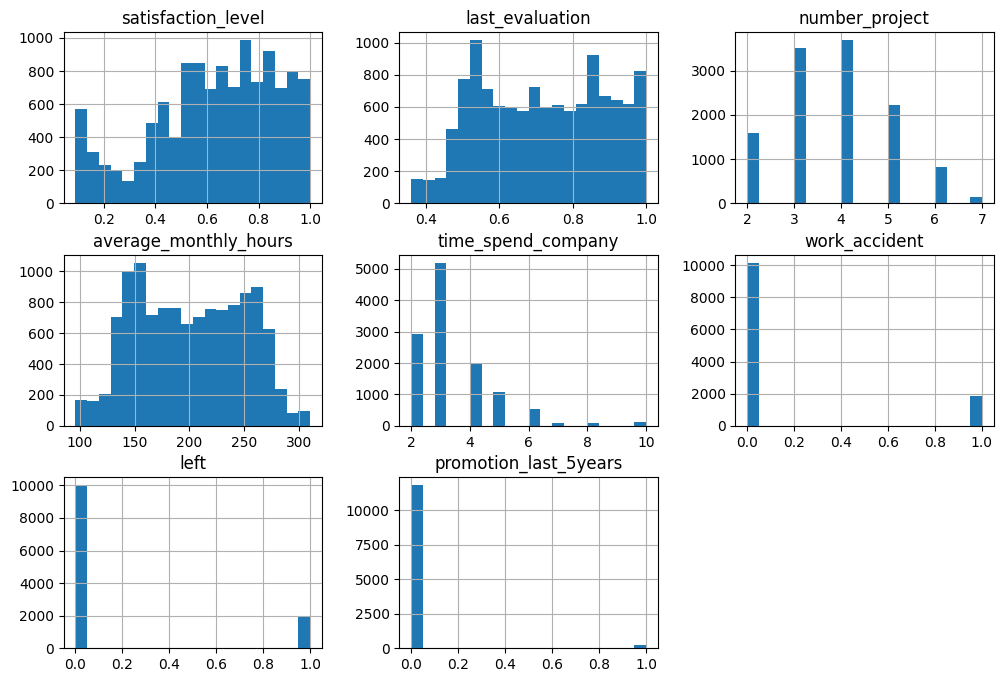

In [14]:
df1.hist(figsize=(12, 8), bins=20)
plt.show()

Insights from histograms above:

**Satisfaction level** - bimodal distribution. It suggests that there is a big cluster of unsatisfied employees scoring around 0.1 alongside a larger group with moderate to high satisfaction;

**Last evaluation** - bimodal distribution again. Two distinct groups can be described as average performers and high performers;

**Number of projects** - most employees hadle 3-4 projects, 6-7 are rarer;

**Average monthly hours** - bimodal distribution. There seems to be two distinct groups with one working a lot more than the other;

**Time spent in company** - right-skewed distribution, with the majority of employees working 2-4 years;

**Work accidents, left and promotion in last 5 years** - prove what was described in Data Understanding phase.


Bimodal distributions in satisfaction level, evaluation and average monthly hours suggest existence of employee subgroups. Further analysis is needed.

Now catergorical data will be assessed as well.

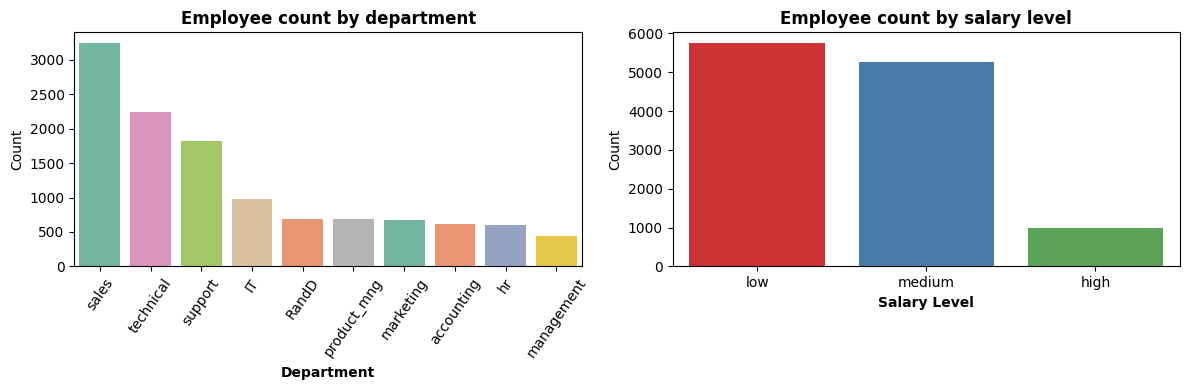

In [15]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Employee count by department
sns.countplot(data=df1, x='department', hue='department', legend=False, ax=axes[0],
              order=df1['department'].value_counts().index, palette='Set2')
axes[0].set_title('Employee count by department', fontweight='bold')
axes[0].set_xlabel('Department', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=55)

# Employee count by salary
sns.countplot(data=df1, x='salary', hue='salary', legend=False, ax=axes[1],
              order = ['low', 'medium', 'high'], palette='Set1')
axes[1].set_title('Employee count by salary level', fontweight='bold')
axes[1].set_xlabel('Salary Level', fontweight='bold')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

**Sales** department is the **biggest one** by significant margin, followed by **technical** and **support**. The **salary** distribution is **heavily skewed towards low and medium** categories, which can indicate that the majority of employees is not satisfied with their current earnings.

### Bivariate Analysis

#### Numeric variables

Variables will be examined in relation to the target variable `left` to identify potential predictors of employee turnover.

In [16]:
df1.groupby('left')[['satisfaction_level', 'last_evaluation', 'number_project',
                     'average_monthly_hours', 'time_spend_company']].mean()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company
left,,,,,
0,0.667365,0.715667,3.786800,198.94270,3.262000
1,0.440271,0.721783,3.883476,208.16223,3.881467


Employees who left the company reported significantly **lower satisfaction** (**0.44 vs 0.67**) and **worked slightly more hours** (**208 vs 198**) on average. Last evaluation scores are nearly identical, which means that it can't be used as a turnover predictor. Employees who left have also worked in a company for longer periods of time.

**Dissatisfaction** and **overwork** appear to be one of the main drivers of employee turnover.

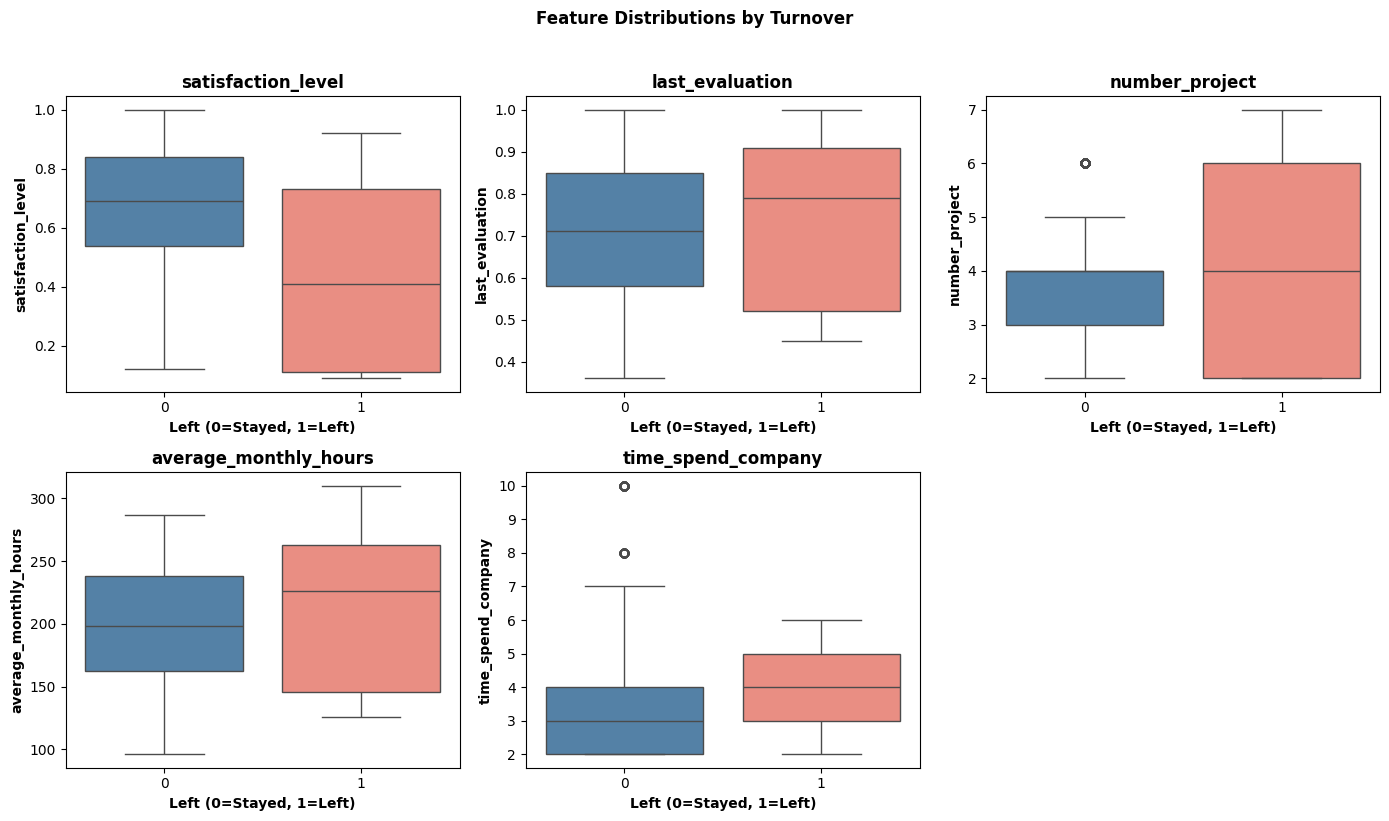

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

numerical_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 
                  'average_monthly_hours', 'time_spend_company']

for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(data=df1, x='left', y=col, ax=ax,
                hue='left', legend=False,
                palette={0: 'steelblue', 1: 'salmon'})
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Left (0=Stayed, 1=Left)', fontweight='bold')
    ax.set_ylabel(col, fontweight='bold')

axes[1, 2].set_visible(False)

plt.suptitle('Feature Distributions by Turnover', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Box plots **confirm assumptions** made earlier. **Satisfaction level** shows the **most pronounced difference** between leavers and stayers with stayers scoring a median of **0.7** and compared to just **0.4** for leavers. **Last evaluation scores** show **high variance among leavers**, which means that both low and high performers are at risk of leaving. Employees who left also work **more hours**, handle **more projects** and have a **slightly longer tenure** (**3.88 vs 3.26 years**).

#### Categorical variables

Turnover rates by department will be examined below.

In [18]:
df1.groupby('department')['left'].mean().sort_values(ascending = False)

department
hr             0.188020
accounting     0.175523
technical      0.173797
support        0.171334
sales          0.169805
marketing      0.166419
IT             0.161885
product_mng    0.160350
RandD          0.122478
management     0.119266
Name: left, dtype: float64

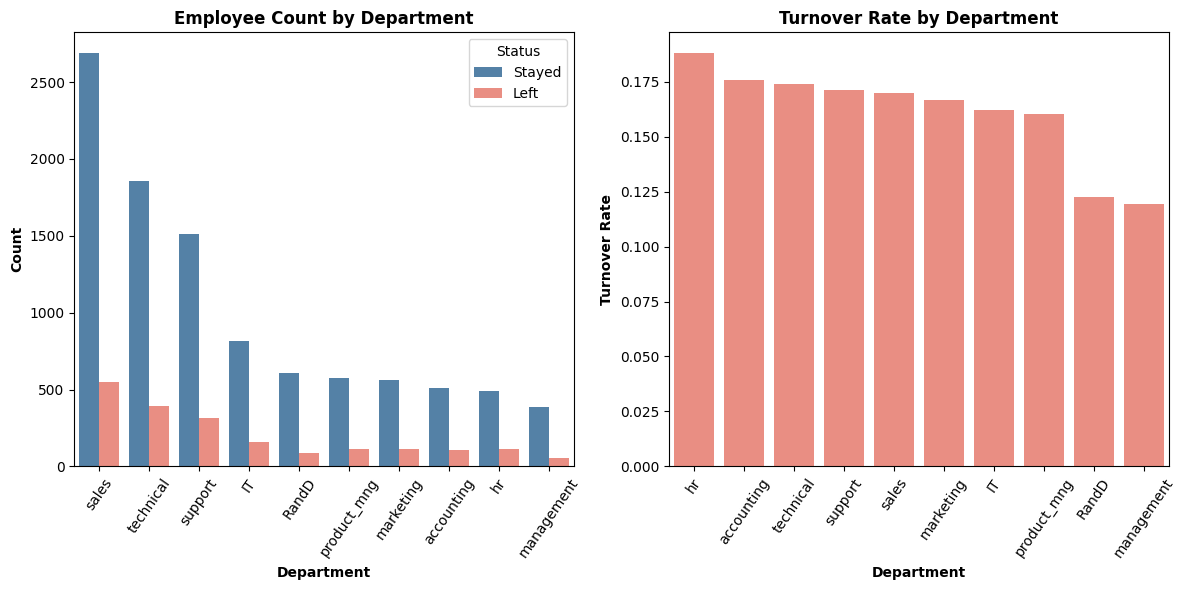

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,6)) 

# Count plot
sns.countplot(data=df1, x='department', order=df1['department'].value_counts().index, 
              hue='left', ax=axes[0], palette={0: 'steelblue', 1: 'salmon'})
axes[0].set_title('Employee Count by Department', fontweight='bold')
axes[0].set_xlabel('Department', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].legend(labels=['Stayed', 'Left'], title='Status')
axes[0].tick_params(axis='x', rotation=55)

# Turnover rate plot
turnover_by_dept = df1.groupby('department')['left'].mean().sort_values(ascending=False).reset_index()
turnover_by_dept.columns = ['department', 'turnover_rate']

sns.barplot(data=turnover_by_dept, x='department', y='turnover_rate', color='salmon', ax=axes[1])
axes[1].set_title('Turnover Rate by Department', fontweight='bold')
axes[1].set_xlabel('Department', fontweight='bold')
axes[1].set_ylabel('Turnover Rate', fontweight='bold')
axes[1].tick_params(axis='x', rotation=55)

plt.tight_layout()
plt.show()

Turnover has **moderate variation** across departments, ranging from **11.9%** in **management** to **18.8%** in **HR**. Lower turnover in management and R&D could reflect higher compensation and/or more engaging work. Notably, HR department, which is mainly responsible for employee retention, paradoxically, has the highest turnover. <br>However, the range across departments is narrow, so it suggests that turnover is a **company-wide issue** and isn't isolated to specific departments.

Turnover rates by salary level will be examined below.

In [20]:
df1.groupby('salary')['left'].mean().sort_values(ascending = False)

salary
low       0.204530
medium    0.146170
high      0.048485
Name: left, dtype: float64

The results are visualised below.

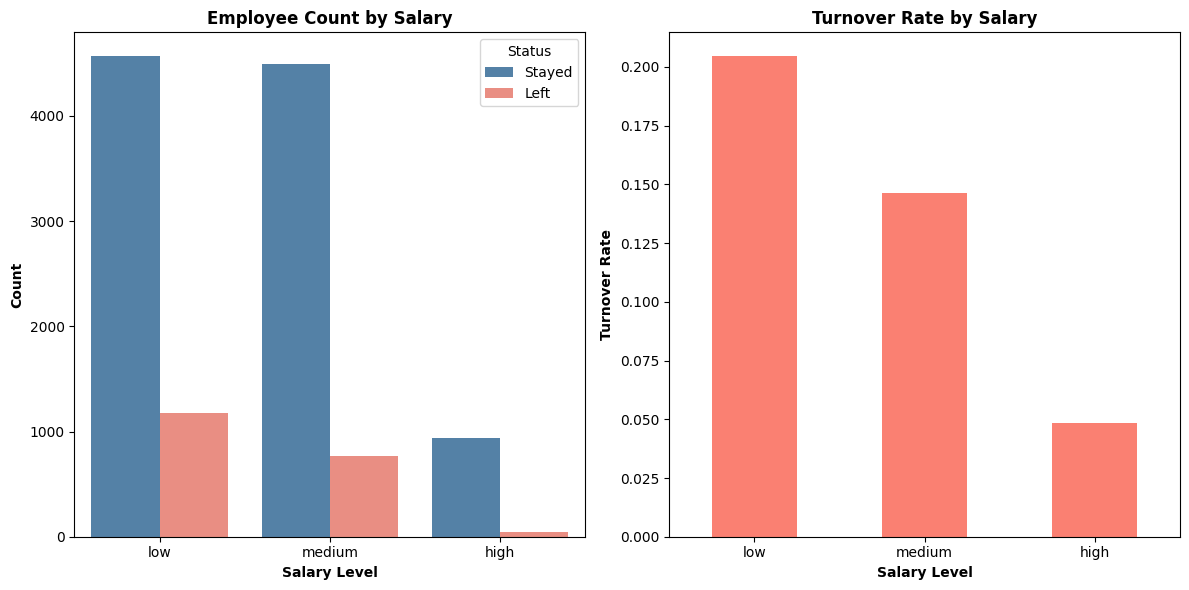

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12,6)) 

# Count plot
sns.countplot(data=df1, x='salary', hue='left', order=['low', 'medium', 'high'], ax=axes[0], palette={0: 'steelblue', 1: 'salmon'})
axes[0].set_title('Employee Count by Salary', fontweight='bold')
axes[0].set_xlabel('Salary Level', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].legend(labels=['Stayed', 'Left'], title='Status')

# Turnover rate plot
df1.groupby('salary')['left'].mean().reindex(['low', 'medium', 'high']).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Turnover Rate by Salary', fontweight='bold')
axes[1].set_xlabel('Salary Level', fontweight='bold')
axes[1].set_ylabel('Turnover Rate', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Salary level has a strong and clear relationship with turnover. Employees who report **low** salaries leave at a rate of **20.5%**, compared to just **4.8%** for **high** earners. The difference is more than fourfold. Employees with **medium** salary leave at a **14.6%** rate. <br>These results suggest that **compensation is one of the primary drivers of employee turnover** at Salifort Motors, and that salary adjustments could help solve the problem.

### Pairplot Analysis

The pairplot below visualises relationships between all numerical variables simultaneously. This will help identify which variable combinations have the strongest and clearest correlation.

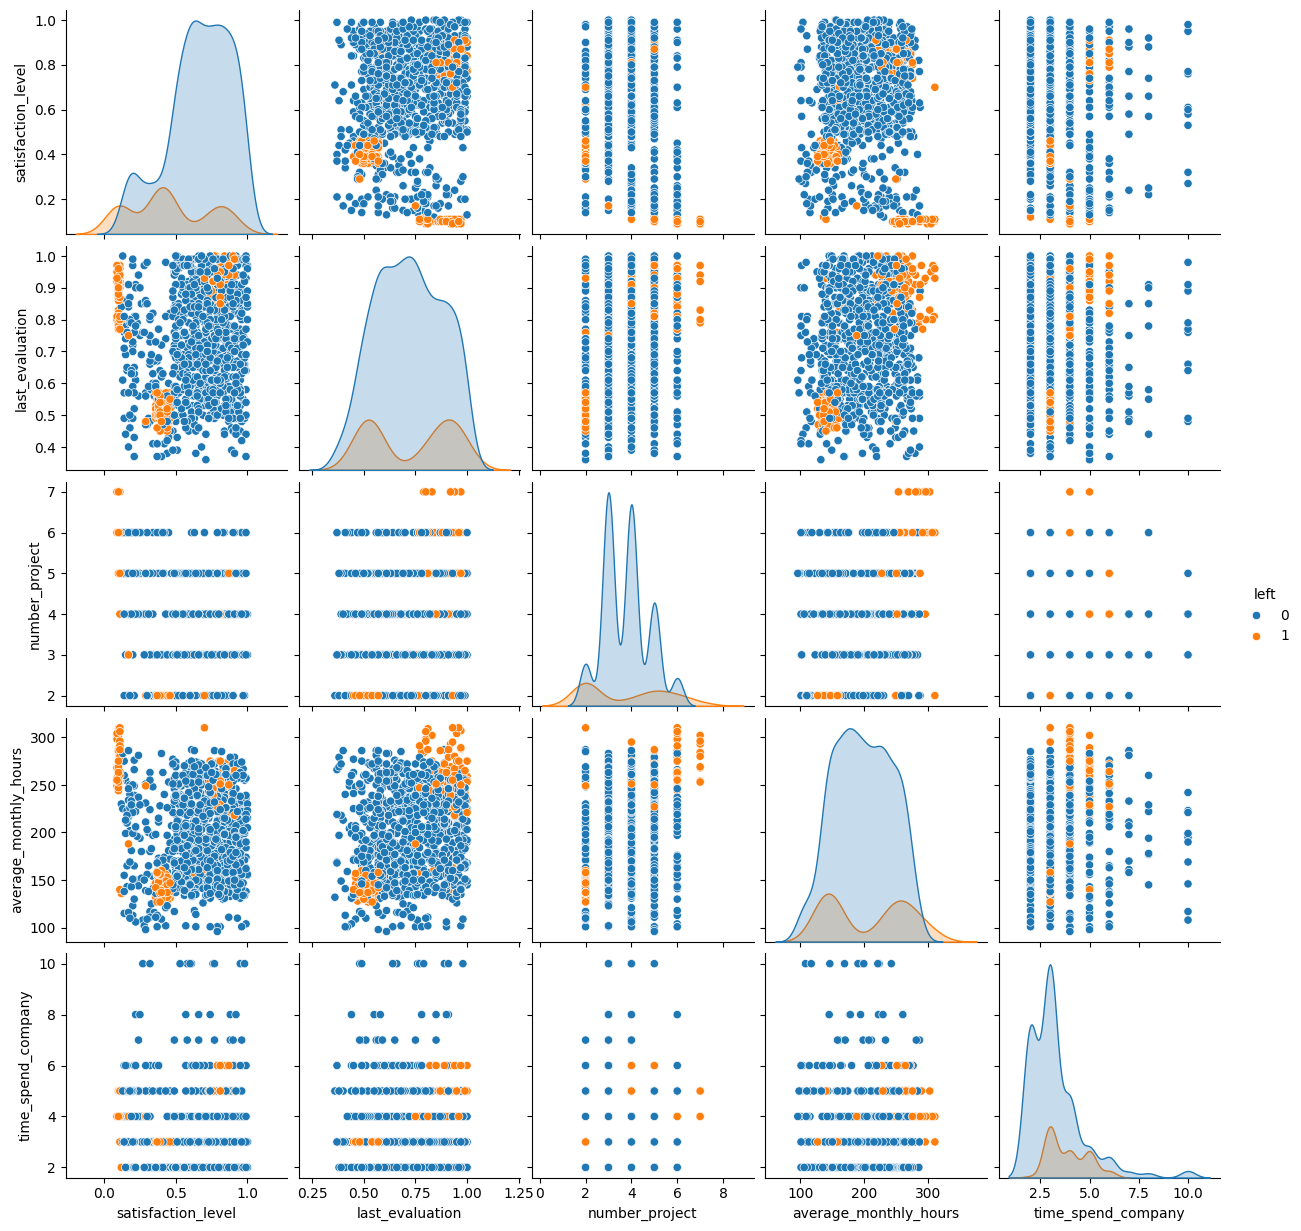

In [22]:
sns.pairplot(data = df1.sample(1000), hue = 'left', 
             vars=['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours',
                   'time_spend_company'])

#### Key Findings:

**Three distinct leaver profiles** can be identified using the pairplot. The **first** one consists of **underperformers with low satisfaction and low workload** - these are likely disengaged employees who have already mentally checked out. The **second** group represents **high performers with heavy workloads and low satisfaction** - employees who have burned out. The **third**, the smallest one of the three groups, consists of **high performers with high satisfaction despite heavy workloads**, potentially leaving due to better external opportunities or undetected dissatisfaction - a hypothesis supported by the low promotion rate and strong salary-turnover correlation identified earlier.

Notably, a **U-shaped relationship with turnover appears across multiple variables** - **number of projects, average monthly hours, and last evaluation** all show higher turnover at **both extremes**. This pattern is consistent with the distinct leaver archetypes identified above.

It was also noted that many employees with **high workload** and **5-7 projects** tend to **leave** the company after **3-5 years** of tenure, possibly due to growing dissatisfaction with lack of career progression.

### Multivariate scatter plots

Key variable relationships identified in the pairplot will be examined more closely using scatter plots to confirm observations.

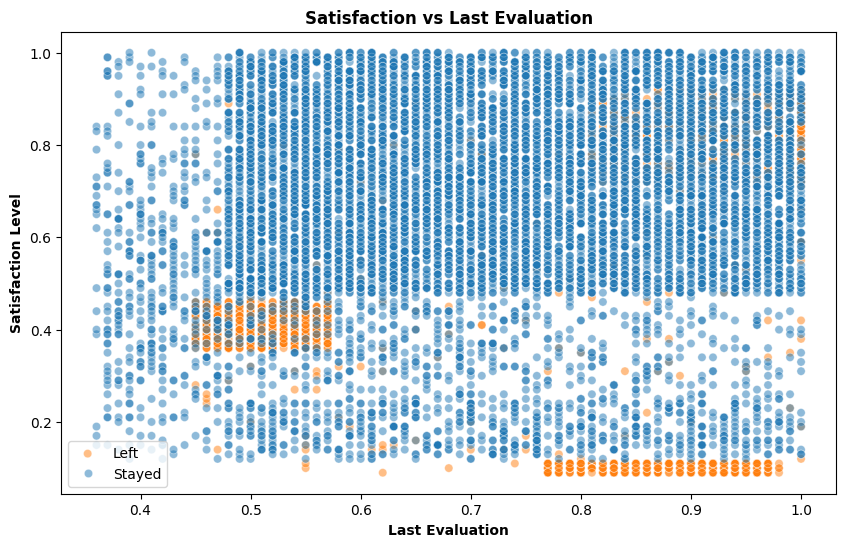

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df1, x='last_evaluation', 
                y='satisfaction_level',
                hue='left',
                alpha=0.5)
plt.title('Satisfaction vs Last Evaluation', fontweight='bold')
plt.xlabel('Last Evaluation', fontweight='bold')
plt.ylabel('Satisfaction Level', fontweight='bold')
plt.legend(labels=['Left', 'Stayed'])
plt.show()

The satisfaction vs last evaluation scatter plot reveals the existence of **two distinct leaver clusters**. The first group consists of **underperformers** scoring around **0.45-0.58 on evaluation** and **0.38-0.48 on satisfaction**. The second, more striking cluster shows **high performers** scoring **0.77-0.98 on evaluation** and just around **0.1 on satisfaction** - suggesting some of the company's best performers are among the most dissatisfied employees. The combination of high performance and low satisfaction could indicate that these employees feel **undervalued and/or unrewarded for their contributions**.

A **third potential group** was observed in the pairplot - high performers with high satisfaction - however it is too dispersed in this plot to confirm as a distinct pattern. This will be investigated further using K-means clustering.

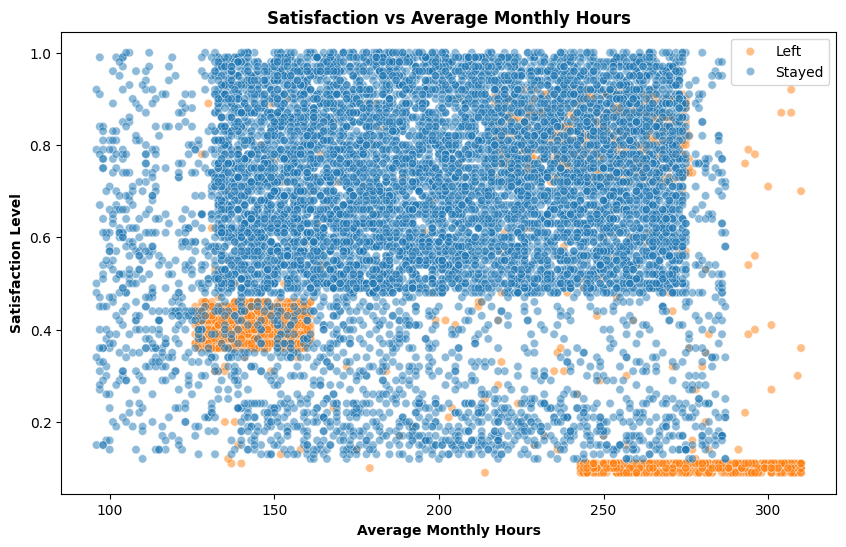

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df1, x='average_monthly_hours', 
                y='satisfaction_level',
                hue='left',
                alpha=0.5)
plt.title('Satisfaction vs Average Monthly Hours', fontweight='bold')
plt.xlabel('Average Monthly Hours', fontweight='bold')
plt.ylabel('Satisfaction Level', fontweight='bold')
plt.legend(labels=['Left', 'Stayed'])
plt.show()

The satisfaction vs average monthly hours scatter plot confirms **two distinct leaver clusters**. The first group works **moderate** hours of around **130-170 per month** with **satisfaction scores of 0.38-0.48**. The second, more concentrated cluster shows employees working **245-310 hours per month** with **satisfaction close to 0.1**, representing severely overworked and deeply dissatisfied employees.

A small dispersion of leavers also appears in the high hours, high satisfaction region, similar to the pattern observed in the previous scatter plot. This potential third group will be investigated further using K-means clustering.

### K-means

To confirm or reject the existence of a third leaver archetype, K-means clsutering will be used to partition leaver data points into three clusters based on `satisfaction_level` and `average_monthly_hours`.


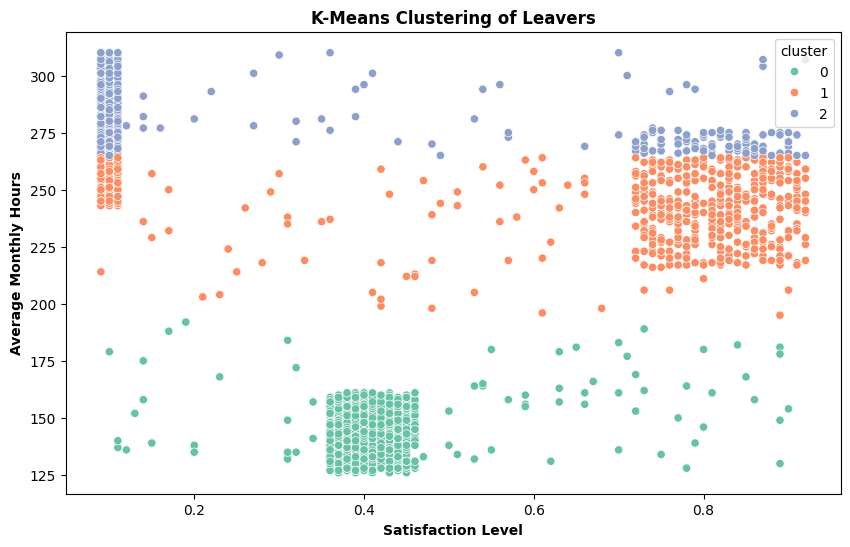

In [25]:
# Data for visualisation
leavers = df1[df1['left'] == 1]
kmeans = KMeans(n_clusters=3, random_state=42)
leavers['cluster'] = kmeans.fit_predict(
    leavers[['satisfaction_level', 'average_monthly_hours']]
)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=leavers, x='satisfaction_level', 
                y='average_monthly_hours', hue='cluster', palette='Set2')
plt.title('K-Means Clustering of Leavers', fontweight='bold')
plt.xlabel('Satisfaction Level', fontweight='bold')
plt.ylabel('Average Monthly Hours', fontweight='bold')
plt.show()

K-means clustering formally confirmed the leaver archetypes identified during EDA. Three clusters were identified - **disengaged underperformers with low satisfaction and low workload** (**cluster 0**), **high performers with high satisfaction and heavy workloads** (**cluster 1**), and a **severely burned out group of high performers with near-zero satisfaction and extreme hours** (**cluster 2**). Cluster 1 is less clearly defined and harder to identify, as its members are largely obscured by stayers with similar working patterns.

However, cluster boundaries show some overlap, reflecting a known limitation of K-means with non-spherical cluster shapes.


### Correlation Heatmap

A correlation heatmap will be used to check for realtionships between variables.

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0, 0.5, 'satisfaction_level'),
  Text(0, 1.5, 'last_evaluation'),
  Text(0, 2.5, 'number_project'),
  Text(0, 3.5, 'average_monthly_hours'),
  Text(0, 4.5, 'time_spend_company'),
  Text(0, 5.5, 'work_accident'),
  Text(0, 6.5, 'left'),
  Text(0, 7.5, 'promotion_last_5years')])

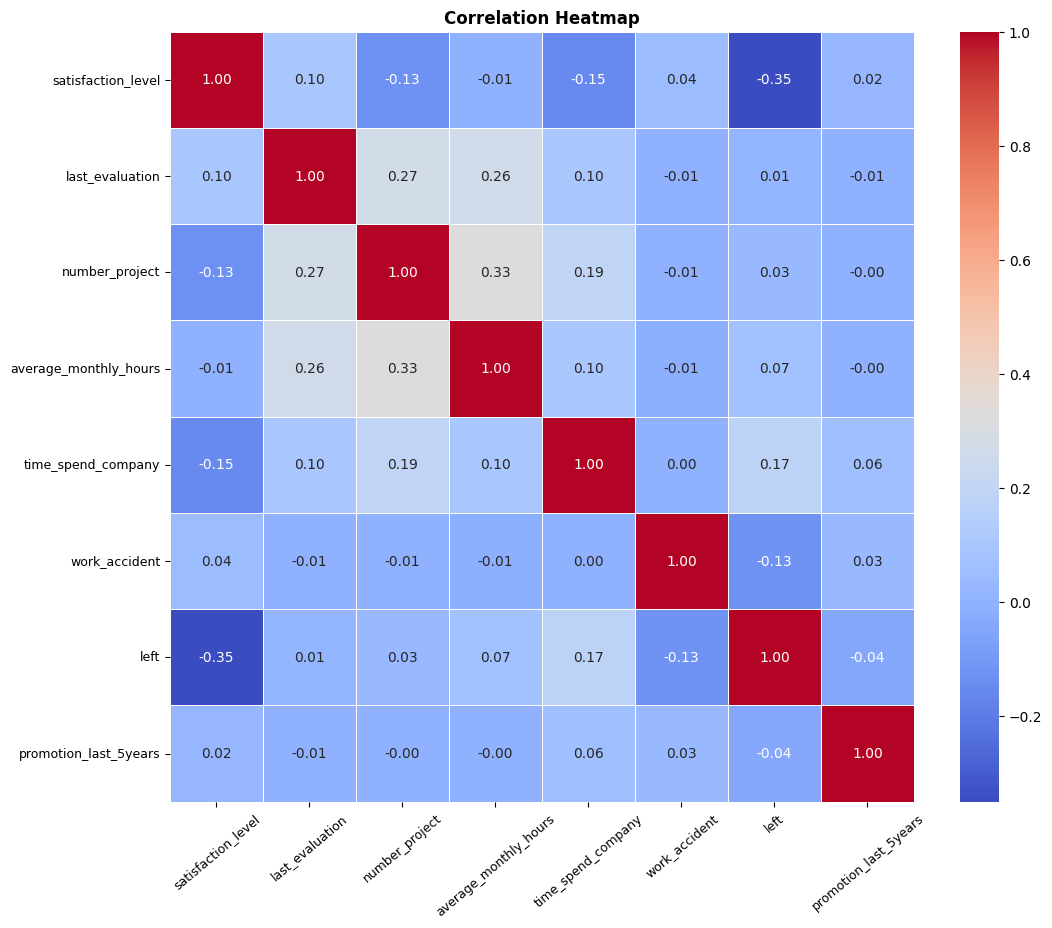

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(data=df1.corr(numeric_only=True), annot=True,
                          cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.xticks(rotation=40, fontsize=9)
plt.yticks(fontsize=9)

The correlation heatmap supports some of the hypotheses suggested earlier:
- **Satisfaction level** is a primary predictor for **turnover** with a correlation of **-0.35**.
- **Average monthly hours** and **number of projects** are moderately correlated scoring **0.33**. It means that more projects means more working hours, which increases burnout risk.
- Employees with higher **evaluation scores** tend to handle more **projects** (**0.26**) and, consequently, have more **working hours** (**0.27**).
- People with longer **tenure** are more likely to **leave** the company (**0.17**), confirming 4-5 year attrition pattern identified earlier.


Notably, there is another finding which seems counterintuitive. People who have experienced a **work-related accident** are **less likely to leave** the company (**-0.13**). This could suggest that employees who experience accidents receive stronger organisational support, making them less likely to leave.

### EDA Summary

- **Satisfaction level** is the **primary predictor** of turnover. Leavers reported significantly lower satisfaction (**0.44 vs 0.67**).
- **Salary** has the **strongest categorical relationship** with turnover. Employees with **low** salaries leave at a rate of **20.5%**, compared to just **4.8%** for **high** earners - a more than fourfold difference.
- **Three distinct employee archetypes** were identified. The **first** one consists of **underperformers with low satisfaction and low workload** - disengaged and mentally checked out employees. The **second** group represents **high performers with heavy workloads and low satisfaction** - employees who have burned out. The third, least visible, group shows **high performers with high satisfaction despite heavy workloads**, potentially leaving due to better external opportunities or undetected dissatisfaction.
- Both leavers and stayers work significantly above standard hours, averaging **208 and 199 hours per month** respectively - approximately **25-30% above the standard** 160-170 monthly hours, suggesting overwork is a **company-wide issue**, not isolated to employees who leave.
- Many employees with **high workload** and **5-7 projects** tend to **leave** the company after **3-5 years** of tenure, possibly due to growing dissatisfaction with lack of career progression.
- Turnover has **moderate variation** across departments, ranging from **11.9%** in **management** to **18.8%** in **HR**, suggesting that turnover is a **company-wide issue** and isn't isolated to specific departments.

These findings suggest that **satisfaction level, salary, average monthly working hours, last evaluation, number of projects and tenure** will likely be the **strongest** predictors in the model.

## Feature Engineering

Before modelling, categorical variables have to be encoded. Salary is ordinally encoded (low = 0, medium = 1, high = 2), as it has a natural order. Department is one-hot encoded, as there is no meaningful order.

In [27]:
# Create a copy used for modeling
df_model = df1.copy()

# Encode salary
salary_map = {'low': 0, 'medium': 1, 'high': 2}
df_model['salary'] = df_model['salary'].map(salary_map)

# Encode department
df_model = pd.get_dummies(df_model, columns=['department'], dtype=int)

# Verify
df_model.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [28]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11991 non-null  float64
 1   last_evaluation         11991 non-null  float64
 2   number_project          11991 non-null  int64  
 3   average_monthly_hours   11991 non-null  int64  
 4   time_spend_company      11991 non-null  int64  
 5   work_accident           11991 non-null  int64  
 6   left                    11991 non-null  int64  
 7   promotion_last_5years   11991 non-null  int64  
 8   salary                  11991 non-null  int64  
 9   department_IT           11991 non-null  int64  
 10  department_RandD        11991 non-null  int64  
 11  department_accounting   11991 non-null  int64  
 12  department_hr           11991 non-null  int64  
 13  department_management   11991 non-null  int64  
 14  department_marketing    11991 non-null  int64  
 15  d

Categorical variables were encoded prior to modelling. **Salary was encoded ordinally** (low = 0, medium = 1, high = 2) and **department was one-hot encoded**, which created **10 additional binary columns**.

No additional features were engineered as the existing variables already capture patterns identified during EDA stage. The model will identify relevant patterns in the raw data on its own.

The resulting dataset contains **11,991 observations and 19 features**.

## Modelling

### Model choice

For further analysis a **Random Forest Classifier** has been chosen. The main reasons are:
- EDA showed that relationships between variables and turnover are **non-linear**. 
- **Multiple distinct leaver clusters** and **U-shaped patterns** were found across several variables - Random Forest handles these kinds of patterns well.
- Random Forest provides **feature importance scores**, which helps understand what drives turnover - a key part of the business objective.
- Random Forest handles **class imbalance** (**83/17**) effectively using `class_weight='balanced'`.
- It **works well with outliers** and does not require feature scaling.

A **logistic regression** model was considered as an alternative but rejected as it assumes linear relationships between features and the target variable, which doesn't match what was found during EDA.


### Dataset split

The dataset will be split into training and test sets before modelling. The model will be trained on the training set and evaluated on the test set to see how well it performs on new data it hasn't seen before.

In [29]:
X = df_model.drop(columns=['left'])
y = df_model['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (9592, 18)
Test set: (2399, 18)


The dataset was split into training (80%) and test (20%) sets, resulting in 9,592 training and 2,399 test samples. `stratify=y` was used to maintain the original class balance across both sets.

### Baseline model

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

The model has been created using default hyperparameters to see how it performs before tuning. Hyperparameters will be adjusted if the initial results aren't good enough.

The model will be used to generate predictions on the test set. These predictions will then be evaluated using key metrics - accuracy, precision, recall and F1 score.

In [31]:
# Predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {auc:.4f}')

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.99      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.98      0.98      2399

ROC-AUC: 0.9768


The baseline model showed good results on ROC-AUC (**0.977**) and F1 score (**0.95**) for leavers. However, recall for the leaver class is at **0.92**, which means that approximately **8%** of employees at risk of leaving are not identified.

The model will be evaluated on the training set to check for overfitting by comparing training and test performance.

In [32]:
y_pred_train = rf_model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7999
           1       1.00      1.00      1.00      1593

    accuracy                           1.00      9592
   macro avg       1.00      1.00      1.00      9592
weighted avg       1.00      1.00      1.00      9592



**100% training accuracy** compared to **98% on the test set** confirms **overfitting**, which means that the model memorised the training set instead of learning patterns. Hyperparameter tuning is needed to improve the model.

### First round of hyperparameter tuning

For hyperparameter tuning **GridSearchCV** will be used to find the optimal combination of hyperparameters - specifically `max_depth`, `min_samples_leaf` and `n_estimators`. Each combination will be evaluated using **cross-validation**. All hyperparameters will be optimized for **ROC-AUC** which evaluates performance of a model across all possible thresholds.

In [33]:
# Setting parameters
cv_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight':['balanced']
    }

# Scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Hyperparameter tuning
rf_tuned = GridSearchCV(rf_model, cv_params, scoring=scoring, cv=4, refit='roc_auc')

# Fitting test data
rf_tuned.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [34]:
rf_tuned.best_params_

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 2,
 'n_estimators': 300}

In [51]:
print(f'Best ROC-AUC: {rf_tuned.best_score_:.4f}')

Best ROC-AUC: 0.9831


The hyperparameters were tuned using GridSearchCV optimising for **ROC-AUC** by testing **60 different combinations**, each evaluated across **4 cross-validation folds**. The best parameters found were `n_estimators=300`, `max_depth=None` and `min_samples_leaf=2`. The best cross-validation **ROC-AUC** score was **0.9831**.

Tuned model will be evaluated using the same process as the baseline model.

In [36]:
# Predictions
y_pred_tuned = rf_tuned.best_estimator_.predict(X_test)
y_pred_proba_tuned = rf_tuned.best_estimator_.predict_proba(X_test)

# Classification report
print(classification_report(y_test, y_pred_tuned))

# ROC-AUC
auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned[:, 1])
print(f'ROC-AUC: {auc_tuned:.4f}')

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.99      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399

ROC-AUC: 0.9805


In [37]:
y_pred_train_tuned = rf_tuned.best_estimator_.predict(X_train)
print(classification_report(y_train, y_pred_train_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7999
           1       0.99      0.99      0.99      1593

    accuracy                           1.00      9592
   macro avg       0.99      0.99      0.99      9592
weighted avg       1.00      1.00      1.00      9592



The tuned model performs similarly to the baseline on the test set, with an **f1-score of 0.95** on leavers and a slightly improved **ROC-AUC of 0.98** compared to **0.977** for the baseline. However, **training accuracy** remains at **100%**, which suggests that the model is still overfitting despite tuning. The reason is likely `max_depth=None` being selected.

### Second round of hyperparameter tuning

The process of tuning hyperparameters will be repeated with `max_depth=None` excluded to avoid unlimited tree growth.

In [38]:
# Setting parameters
cv_params_v2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 20],
    'class_weight':['balanced']
    }

# Scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Hyperparameter tuning
rf_tuned_v2 = GridSearchCV(rf_model, cv_params_v2, scoring=scoring, cv=4, refit='roc_auc')

# Fitting test data
rf_tuned_v2.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [39]:
rf_tuned_v2.best_params_

{'class_weight': 'balanced',
 'max_depth': 20,
 'min_samples_leaf': 2,
 'n_estimators': 100}

In [40]:
print(f'Best ROC-AUC: {rf_tuned_v2.best_score_:.4f}')

Best ROC-AUC: 0.9830


In [41]:
# Predictions
y_pred_tuned_v2 = rf_tuned_v2.best_estimator_.predict(X_test)
y_pred_proba_tuned_v2 = rf_tuned_v2.best_estimator_.predict_proba(X_test)

# Classification report
print(classification_report(y_test, y_pred_tuned_v2))

# ROC-AUC
auc_tuned_v2 = roc_auc_score(y_test, y_pred_proba_tuned_v2[:, 1])
print(f'ROC-AUC: {auc_tuned:.4f}')

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399

ROC-AUC: 0.9805


In [42]:
y_pred_train_tuned_v2 = rf_tuned_v2.best_estimator_.predict(X_train)
print(classification_report(y_train, y_pred_train_tuned_v2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7999
           1       0.99      0.98      0.99      1593

    accuracy                           1.00      9592
   macro avg       0.99      0.99      0.99      9592
weighted avg       1.00      1.00      1.00      9592



For the second version of the model the following parameters were chosen as optimal: `max_depth=20`, `min_samples_leaf=2`. The **precision for leavers dropped** from **0.99 to 0.98** and **ROC-AUC remained stable**, so the overall **predictive performance remained the same**. However, **training accuracy remained at 100%**, confirming **overfitting wasn't resolved**. A third round with stricter depth constraints will be performed. 

### Third round of hyperparameter tuning

In [43]:
# Setting parameters
cv_params_v3 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20],
    'class_weight':['balanced']
    }

# Scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Hyperparameter tuning
rf_tuned_v3 = GridSearchCV(rf_model, cv_params_v3, scoring=scoring, cv=4, refit='roc_auc')

# Fitting test data
rf_tuned_v3.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [44]:
rf_tuned_v3.best_params_

{'class_weight': 'balanced',
 'max_depth': 7,
 'min_samples_leaf': 5,
 'n_estimators': 100}

In [45]:
print(f'Best ROC-AUC: {rf_tuned_v3.best_score_:.4f}')

Best ROC-AUC: 0.9817


In [46]:
# Predictions
y_pred_tuned_v3 = rf_tuned_v3.best_estimator_.predict(X_test)
y_pred_proba_tuned_v3 = rf_tuned_v3.best_estimator_.predict_proba(X_test)

# Classification report
print(classification_report(y_test, y_pred_tuned_v3))

# ROC-AUC
auc_tuned_v3 = roc_auc_score(y_test, y_pred_proba_tuned_v3[:, 1])
print(f'ROC-AUC: {auc_tuned:.4f}')

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2001
           1       0.93      0.92      0.93       398

    accuracy                           0.98      2399
   macro avg       0.96      0.96      0.96      2399
weighted avg       0.98      0.98      0.98      2399

ROC-AUC: 0.9805


In [47]:
y_pred_train_tuned_v3 = rf_tuned_v3.best_estimator_.predict(X_train)
print(classification_report(y_train, y_pred_train_tuned_v3))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7999
           1       0.94      0.92      0.93      1593

    accuracy                           0.98      9592
   macro avg       0.96      0.95      0.96      9592
weighted avg       0.98      0.98      0.98      9592



The third tuning round successfully **resolved overfitting** - **training accuracy** dropped from **100%** to **98%**, confirming that this version of the model learned patterns instead of memorising the training data. ROC-AUC remained stable at **0.981**. However, **F1 score** for leavers dropped from **0.95** to **0.93**, representing an acceptable tradeoff for improved generalisation. 

Overall, this version of the model is selected as the **final one**, as its prediction performance remained high, while also resolving the overfitting issue present in earlier versions.

The model's prediction will be visualised using a confusion matrix, which will help determine how many leavers were successfully identified and how many were missed.

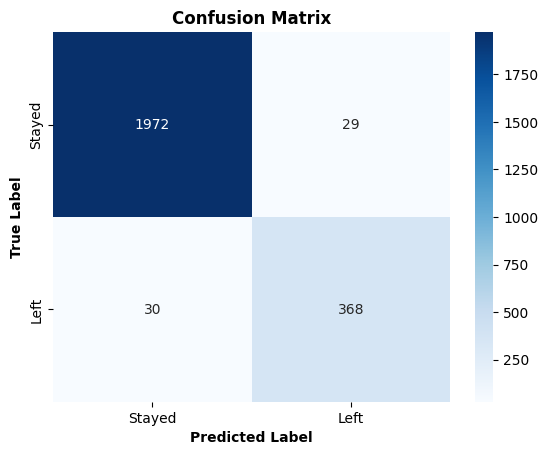

In [48]:
cm = confusion_matrix(y_test, y_pred_tuned_v3)
sns.heatmap(data=cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.show()

The confusion matrix shows the model correctly identified **368 out of 398** actual leavers, missing only **30** - approximately **7.5%** of at-risk employees. **29** employees were flagged incorrectly as being at risk, representing a manageable number of false alarms.

### Feature importance

One of the main business goals of the capstone was to identify the key drivers of employee turnover. Feature importance scores from the final model will be used to answer this question.

In [49]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_tuned_v3.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

                   feature  importance
0       satisfaction_level    0.291587
4       time_spend_company    0.249235
2           number_project    0.175792
1          last_evaluation    0.134130
3    average_monthly_hours    0.124745
5            work_accident    0.011033
7                   salary    0.007729
6    promotion_last_5years    0.001319
15        department_sales    0.000889
12   department_management    0.000649
17    department_technical    0.000567
16      department_support    0.000539
9         department_RandD    0.000529
10   department_accounting    0.000322
11           department_hr    0.000316
8            department_IT    0.000249
14  department_product_mng    0.000201
13    department_marketing    0.000169


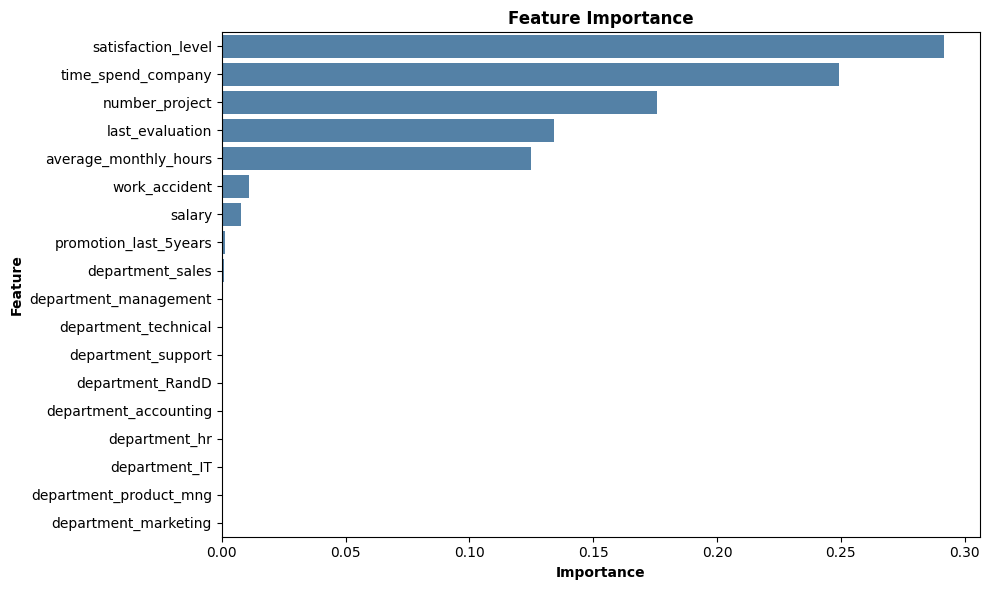

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', color='steelblue')
plt.title('Feature Importance', fontweight='bold')
plt.xlabel('Importance', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')
plt.tight_layout()
plt.show()

Feature importance analysis confirmed `satisfaction_level` to be the strongest predictor of turnover (**0.29**), consistent with EDA findings. `time_spend_company` (**0.25**), `number_project` (**0.18**), `last_evaluation` (**0.13**) and `average_monthly_hours` (**0.12**) should also be considered important drivers. Department features show near-zero importance, confirming turnover is a company-wide issue and is not isolated to specific departments. Notably, `salary` scored low despite showing strong effect during EDA, possibly because it was encoded.

## Results & Recommendations

EDA provided many findings suggesting a **Random Forest Classifier** would be the best fit for the analysis of employee turnover - non-linear relationships between variables and turnover, the existence of U-shaped patterns and three distinct employee clusters, class imbalance and business goal of determining feature importance.

**Three distinct employee archetypes** were identified - **underperformers with low satisfaction and low workload**,  **high performers with heavy workloads and low satisfaction**, and a **less visible group of high performers with high satisfaction despite heavy workloads**, possibly leaving due to external opportunities or undetected dissatisfaction. The first two groups share low satisfaction despite very different working patterns, suggesting satisfaction is a symptom of multiple underlying issues.

The baseline model showed overfitting with 100% training accuracy and was tuned 3 times to resolve this. The final version of the model had the following scores: **F1** for leavers - **0.93**, **ROC-AUC** - **0.981**. The confusion matrix showed that on the test data the model correctly identified **368 out of 398** actual leavers and only **29** employees were flagged incorrectly as being at risk.

The main drivers of employee turnover were `satisfaction_level` (**0.29**), `time_spend_company` (**0.25**), `number_project` (**0.18**), `last_evaluation` (**0.13**) and `average_monthly_hours` (**0.12**). These findings are consistent with EDA results, confirming the model learned genuine patterns.

Recommendations:
- **Satisfaction levels** should be closely monitored - especially among employees with **high workloads** and **5-7 projects**.
- **Salaries** should be reviewed - low earners leave at **20.5%** compared to **4.8%** for high earners.
- **Workload** should be addressed company-wide. Both leavers and stayers average well above standard monthly hours (**208 and 199** respectively compared to a standard **160-170**).
- Particular attention should be paid to **employees with 5-7 projects** and **3-5 years tenure** - **highest risk group identified in EDA**.
- The **promotion pipeline** should be reviewed - only **2.1%** of employees were promoted in 5 years, likely driving dissatisfaction among high performers.

This analysis successfully built a Random Forest model capable of identifying employees at risk of leaving with an F1 score of **0.93** and ROC-AUC of **0.981**. The model determined that **satisfaction level**, **tenure**, **number of projects**, **last evaluation** and **average monthly hours** were the primary drivers of employee turnover, which confirms EDA findings. 

These results provide Salifort Motors with both a ready-to-use predictive tool and actionable insights to improve employee retention.